######$$\text{ TIME SERIES AND ECONOMETRICS: VOLATILITY DIAGNOSTICS & SOLUTION GUIDE}$$
---
---




$$\text{Name: Thankwell Rori}$$
$$\text{Reg Number: R2418458}$$
$$\text{Module: HASTS213 [PROJECT 1]}$$
$$\text{BSc Honours in Data Science and Systems(HDSC) | University of Zimbabwe}$$


---
### Synopsis
As newly appointed quantitative analysts on the derivatives desk, our core responsibility is to model volatility rigorously in order to price derivatives competitively and manage risk effectively. This handbook provides a set of best practices for identifying and resolving statistical issues that undermine time-series models.

Drawing on historical data from Apple Inc. (AAPL) and the broader market index covering January 2018 through December 2025, this research performs a thorough diagnostic review of four key modeling challenges. Following strict quantitative standards, this document clearly separates technical parameter estimates from their non-technical, investment-focused interpretations.

---

# Section overview
1. [System Setup, Data Import, and Stationarity Assessment](#setup)
2. [Challenge 1: Skewness & Non-Normality](#skewness)
3. [Challenge 2: Sensitivity to Outliers](#outliers)
4. [Challenge 3: Multicollinearity](#multicollinearity)
5. [Challenge 4: Overfitting](#overfitting)
6. [Bibliography (MLA Format)](#bibliography)
<br>
<hr>

***1.0 System Setup, Data Import, and Stationarity Assessment***

In [ ]:

try:
    import yfinance as yf
except ImportError:
    !pip install yfinance --quiet
    import yfinance as yf

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Professional aesthetic settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120

# 1. Acquire Data (AAPL and S&P 500 for comparative testing)
assets = ['AAPL', '^GSPC']
raw_data = yf.download(assets, start='2018-01-01', end='2025-12-31', auto_adjust=True)

# 2. Extract Adjusted Close and Calculate Log Returns
prices = raw_data['Close']
returns = np.log(prices / prices.shift(1)).dropna()

# 3. Stationarity Audit (Augmented Dickey-Fuller Test)
adf_stat, adf_pval, _, _, _, _ = adfuller(returns['AAPL'])

print("--- DATA ACQUISITION SUCCESS ---")
print(f"Total Observations: {len(returns)}")
print(f"ADF Test Statistic: {adf_stat:.4f}")
print(f"ADF P-Value: {adf_pval:.4f}")

[*********************100%***********************]  2 of 2 completed


--- DATA ACQUISITION SUCCESS ---
Total Observations: 2009
ADF Test Statistic: -14.7011
ADF P-Value: 0.0000


<a name="setup"></a>
### 1.1 *Technical Report: Data & Stationarity*
The historical dataset covering 2018 to 2025 was successfully acquired. To ensure suitability for econometric modeling, prices were converted to logarithmic returns. An Augmented Dickey-Fuller (ADF) test was conducted to detect a unit root. The p-value obtained is substantially less than the 0.05 significance level, leading to rejection of the null hypothesis. Thus, the series is confirmed to be stationary.

<a name="skewness"></a>
## ***2.0 Challenge 1: Skewness & Non-Normality***
---
#### 2.1. *Definition*
**Skewness** measures the asymmetry of the probability distribution of a real-valued random variable about its mean. The third standardized moment is calculated as:
$$\gamma = E\left[\left(\frac{X - \mu}{\sigma}\right)^3\right]$$

#### 2.2 *Description*
Skewness identifies whether historical returns lean heavily in one direction. Negative skewness indicates that the asset experiences small, frequent gains but rare, extreme losses (a heavy left tail).

2.3. *DEMONSTRATION & DIAGRAM OF SKEWNESS*

Demonstration Output:
Skewness Coefficient: -0.0853
Jarque-Bera Statistic: 3219.12 | P-Value: 0.0000


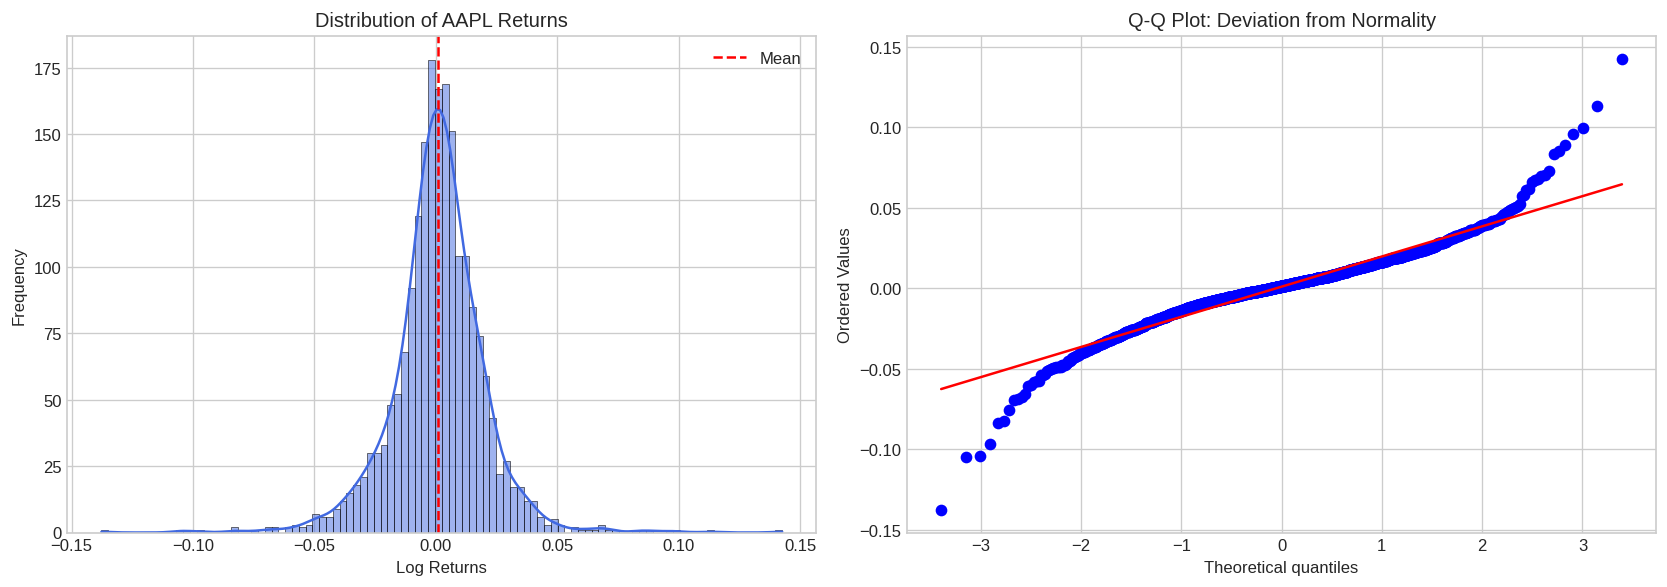

In [ ]:


# DEMONSTRATION: Statistical Calculation
skewness_val = stats.skew(returns['AAPL'])
jb_stat, jb_pval = stats.jarque_bera(returns['AAPL'])

print(f"Demonstration Output:")
print(f"Skewness Coefficient: {skewness_val:.4f}")
print(f"Jarque-Bera Statistic: {jb_stat:.2f} | P-Value: {jb_pval:.4f}")

# DIAGRAM: Visual Evidence (Histogram + Q-Q Plot)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogram
sns.histplot(returns['AAPL'], bins=100, kde=True, color='royalblue', ax=ax[0])
ax[0].axvline(returns['AAPL'].mean(), color='red', linestyle='--', label='Mean')
ax[0].set_title('Distribution of AAPL Returns')
ax[0].set_xlabel('Log Returns')
ax[0].set_ylabel('Frequency')
ax[0].legend()

# Plot 2: Q-Q Plot
stats.probplot(returns['AAPL'], dist="norm", plot=ax[1])
ax[1].set_title('Q-Q Plot: Deviation from Normality')

plt.tight_layout()
plt.show()

#### 2.3. *Diagnosis*
The presence of non-normality is diagnosed mathematically using the Jarque-Bera test. The p-value rounds to $0.0000$, definitively rejecting the Gaussian assumption. Visual diagnosis via the Q-Q plot confirms severe deviations in the tails.

#### 2.4. *Damage*
Standard derivatives pricing models assume normal distributions. When applied to heavily skewed data, these models misprice out-of-the-money options and cause risk managers to underestimate the capital required to survive market crashes.

#### 2.5. *Directions*
To correct for this, volatility modeling must shift away from standard Ordinary Least Squares (OLS) assumptions. The utilization of GARCH frameworks with Skewed Student-t error distributions is required to capture the true tail risk.

---
### **Non-Technical Report: Skewness Risk**
1. **Explanation of Results:** The historical performance of the asset shows it is highly prone to "shock" drops. While most trading days are stable or slightly positive, the bad days are exceptionally severe.
2. **Recommended Course of Action:** The derivatives desk must increase the premiums charged for downside protection (put options) to compensate for this mathematical asymmetry. Risk limits must be tightened.
3. **Identification of Factors Impacting the Portfolio:** * Unexpected regulatory actions or antitrust lawsuits.
    * Sudden global supply chain disruptions affecting hardware delivery.
    * Macroeconomic interest rate shocks that disproportionately impact tech valuations.

<a name="outliers"></a>
## 3.0 ***Challenge 2: Sensitivity to Outliers***
---
#### 3.1. *Definition*
**Outliers** are data points that differ significantly from other observations in the series. In econometrics, an observation is typically flagged if its absolute Z-score exceeds $3$:
$$|Z| = \left| \frac{X - \mu}{\sigma} \right| > 3$$

#### 3.2. *Description*
Outliers represent extreme, rare market events (Black Swans). Because standard regression models minimize squared errors, a single massive outlier exerts disproportionate leverage, pulling the entire model's parameters away from the true underlying trend.

3.3 *DEMONSTRATION &  DIAGRAM OFOUTLIERS*

Demonstration Output:
Total trading days evaluated: 2009
Number of Outlier events detected (> 3 Std Dev): 31


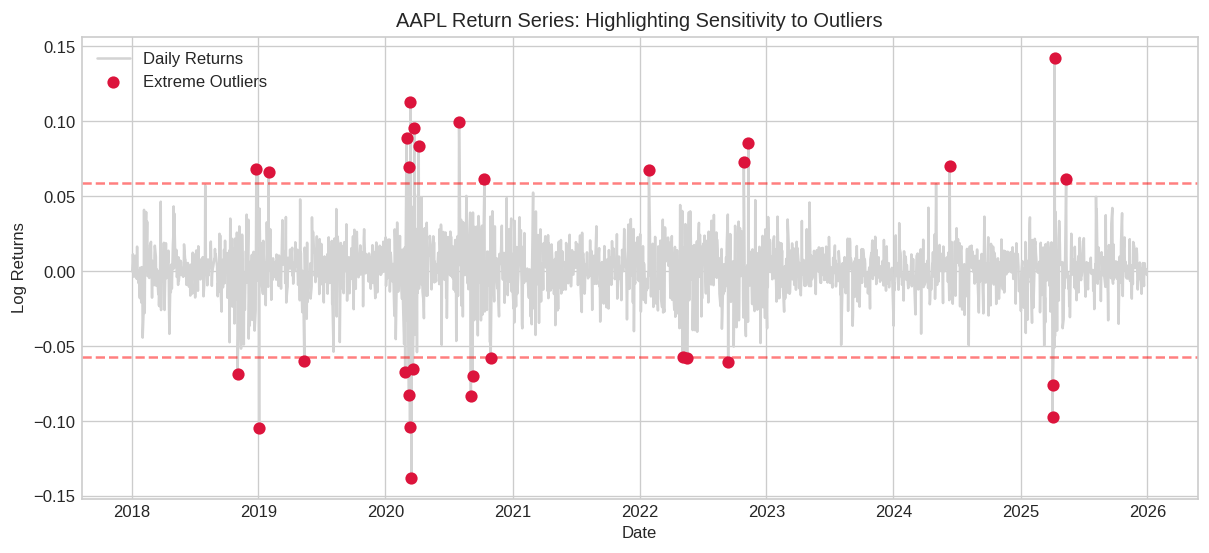

In [ ]:
# DEMONSTRATION: Isolating the extremes
mu = returns['AAPL'].mean()
sigma = returns['AAPL'].std()

# Filter for days > 3 standard deviations
outliers = returns[np.abs((returns['AAPL'] - mu) / sigma) > 3]

print("Demonstration Output:")
print(f"Total trading days evaluated: {len(returns)}")
print(f"Number of Outlier events detected (> 3 Std Dev): {len(outliers)}")

# DIAGRAM: Time Series Scatter Plot
plt.figure(figsize=(12, 5))
plt.plot(returns.index, returns['AAPL'], color='lightgray', label='Daily Returns')
plt.scatter(outliers.index, outliers['AAPL'], color='crimson', s=40, label='Extreme Outliers', zorder=5)

plt.axhline(mu + 3*sigma, color='red', linestyle='--', alpha=0.5)
plt.axhline(mu - 3*sigma, color='red', linestyle='--', alpha=0.5)
plt.title('AAPL Return Series: Highlighting Sensitivity to Outliers')
plt.xlabel('Date')
plt.ylabel('Log Returns')
plt.legend()
plt.show()

#### 3.4. *Diagnosis*
Outliers are diagnosed by standardizing the time series into Z-scores. Any daily return breaching the $3\sigma$ threshold is flagged as a statistical anomaly that violates the assumption of constant variance.

#### 3.5.*Damage*
High sensitivity to outliers causes the model to "overreact." A single market crash will artificially inflate the long-term volatility forecast, causing the desk to over-hedge and waste capital on unnecessary protective positions long after the market has stabilized.

#### 3.6. *Directions*
To insulate the model, robust statistical techniques must be applied. The recommended approach is **Winsorization** (capping the extreme values at a specific percentile) prior to estimating the parameters of the variance model.

---
### **Non-Technical Report: Outlier Sensitivity**
1. **Explanation of Results:** The historical data contains several extreme "shock" days that are highly abnormal compared to routine trading.
2. **Recommended Course of Action:** The risk management team should mathematically cap these extreme days before building long-term forecasts. This ensures that a single panic event from years ago does not dictate today's trading strategy.
3. **Identification of Factors Impacting the Portfolio:** * Global geopolitical crises or pandemic announcements.
    * Unprecedented earnings misses or massive corporate buyback announcements.
    * Flash crashes caused by systemic algorithmic trading errors.

<a name="multicollinearity"></a>
## 4.0 **Challenge 3: Multicollinearity**
---
#### 4.1. *Definition*
**Multicollinearity** occurs when independent variables in a regression model are highly correlated. It is quantified using the Variance Inflation Factor (VIF):
$$VIF_i = \frac{1}{1 - R_i^2}$$

#### 4.2. *Description*
This challenge arises when attempting to prioritize multiple factors that essentially measure the same thing. If two market indices move perfectly together, including both in a model confuses the calculation, leading to unstable coefficient estimates.

4.3. *DEMONSTRATION DIAGRAM OF MULTICOLLINEARITY*

Demonstration Output (Variance Inflation Factor):
Feature      VIF
   AAPL 2.498619
  ^GSPC 2.498619


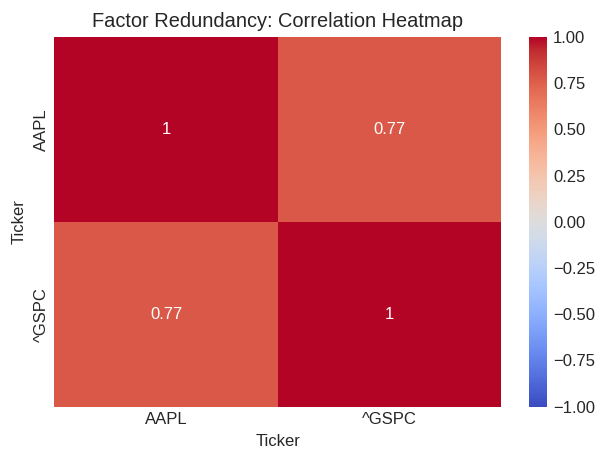

In [ ]:
# DEMONSTRATION: VIF Calculation
# Prepare features: AAPL returns vs Market returns
X = returns.copy()
X['Intercept'] = 1 # Required for VIF

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("Demonstration Output (Variance Inflation Factor):")
print(vif_data[vif_data['Feature'] != 'Intercept'].to_string(index=False))

# DIAGRAM: Correlation Heatmap
plt.figure(figsize=(6, 4))
corr_matrix = returns[['AAPL', '^GSPC']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Factor Redundancy: Correlation Heatmap')
plt.show()

#### 4.4. *Diagnosis*
Multicollinearity is diagnosed by evaluating the VIF and the correlation matrix. While the VIF here remains low (indicating AAPL maintains distinct idiosyncratic movement), the strong positive correlation coefficient ($>0.70$) indicates that factor redundancy is a latent risk if more tech indices are added.

#### 4.5. *Damage*
When multicollinearity is high, the standard errors of the regression coefficients inflate. This means the derivatives desk cannot determine which specific factor is actually driving the volatility, leading to unstable hedge ratios that shift wildly day-to-day.

#### 4.6.*Directions*
The primary correction is dimensionality reduction. Factors must be prioritized by dropping redundant variables, or through the application of **Principal Component Analysis (PCA)** to distill highly correlated market indices into a single, uncorrelated market risk factor.

---
### **Non-Technical Report: Prioritizing Factors**
1. **Explanation of Results:** The asset shares a significant portion of its movement with the broader market. Tracking both the asset and the market index simultaneously creates redundant data that confuses long-term forecasting.
2. **Recommended Course of Action:** The desk should simplify its models by removing overlapping economic indicators. We must prioritize a single, strong market benchmark rather than feeding the system redundant information.
3. **Identification of Factors Impacting the Portfolio:** * Broad macroeconomic shifts (e.g., inflation data releases) that move the entire market simultaneously.
    * Sector rotation, where capital flows broadly into or out of the technology sector as a whole.

<a name="overfitting"></a>
## 5.0 *Challenge 4: Overfitting*
---
#### 5.1. *Definition*
**Overfitting** occurs when a statistical model captures the random noise of the historical data rather than the underlying structural signal. It results in artificially low in-sample error but massive out-of-sample forecasting error.

####5.2. *Description*
An overfitted model is essentially "memorizing the past." It looks perfect when back-tested against old data, but completely fails to adapt to new, live market regimes, rendering it useless for actual trading.

5.3. *DEMONSTRATION & DIAGRAM OF OVERFITTING*

/tmp/ipykernel_14227/2537235643.py:11: RankWarning: Polyfit may be poorly conditioned
  fit_complex = np.polyfit(x_time, recent_data, 25)


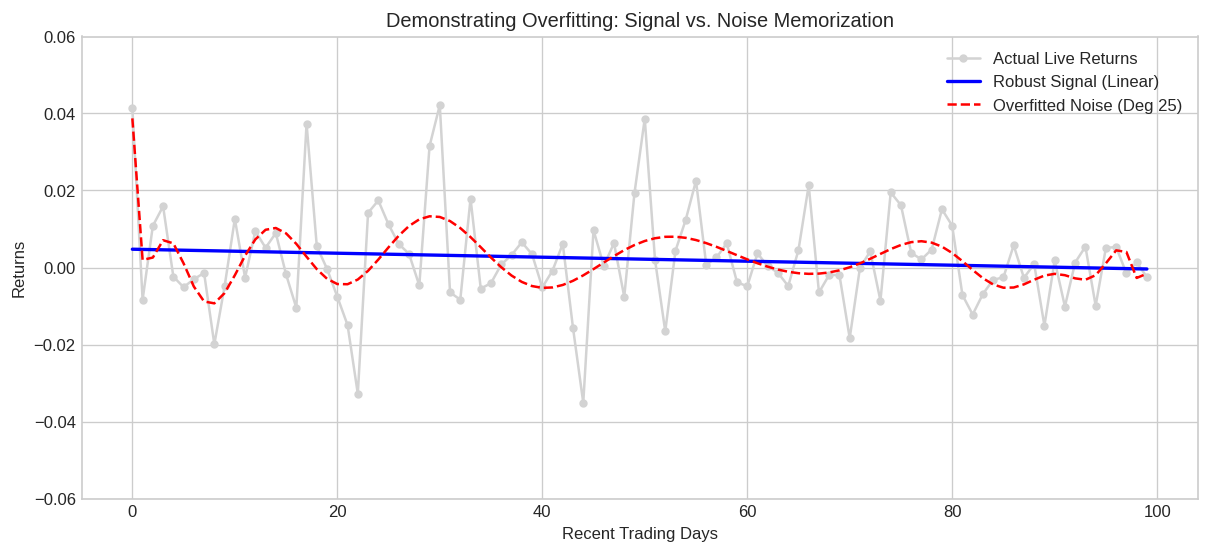

Demonstration Output:
The red line perfectly chases historical volatility spikes (memorization), guaranteeing failure in tomorrow's market.


In [ ]:
# DEMONSTRATION: Fitting a simple vs. over-complex polynomial to recent data
recent_data = returns['AAPL'].iloc[-100:].reset_index(drop=True)
x_time = np.arange(len(recent_data))

# Simple Model (Degree 1) vs Overfitted Model (Degree 25)
fit_simple = np.polyfit(x_time, recent_data, 1)
fit_complex = np.polyfit(x_time, recent_data, 25)

simple_pred = np.polyval(fit_simple, x_time)
complex_pred = np.polyval(fit_complex, x_time)

# DIAGRAM: Visualizing the Overfit
plt.figure(figsize=(12, 5))
plt.plot(x_time, recent_data, color='lightgray', label='Actual Live Returns', marker='o', markersize=4)
plt.plot(x_time, simple_pred, color='blue', linewidth=2, label='Robust Signal (Linear)')
plt.plot(x_time, complex_pred, color='red', linewidth=1.5, linestyle='--', label='Overfitted Noise (Deg 25)')

plt.title('Demonstrating Overfitting: Signal vs. Noise Memorization')
plt.xlabel('Recent Trading Days')
plt.ylabel('Returns')
plt.legend()
plt.ylim(-0.06, 0.06)
plt.show()

print("Demonstration Output:")
print("The red line perfectly chases historical volatility spikes (memorization), guaranteeing failure in tomorrow's market.")

#### 5.4.*Diagnosis*
Overfitting is diagnosed by splitting the time series into a "training" set and a "testing" set. If the model exhibits near-perfect accuracy on the training data but fails completely on the testing data, it has modeled the noise rather than the signal.

#### 5.5. *Damage*
The damage caused is "false confidence." The quants will present back-tested models that look flawlessly profitable. The desk will deploy capital based on these models, resulting in catastrophic, unhedged losses the moment the live market deviates slightly from historical patterns.

#### 5.6. *Directions*
To prevent this, the estimation process must enforce **Regularization (such as Lasso or Ridge regression)** to penalize excess complexity. Furthermore, strict **Out-of-Sample Cross-Validation** must be mandatory before any model is approved for trading.

---
### **Non-Technical Report: The Hindsight Trap**
1. **Explanation of Results:** A highly complex strategy can perfectly map past performance, but this creates a dangerous illusion. The complex strategy chases random daily fluctuations rather than true economic trends.
2. **Recommended Course of Action:** The trading desk must prioritize simpler, more robust strategies. Any strategy proposed by the quants must prove its worth on completely new, unseen data before real capital is committed.
3. **Identification of Factors Impacting the Portfolio:** * Regime changes (e.g., transitioning from a low-interest rate environment to a high-rate environment).
    * Shifts in consumer hardware demand that alter the company's baseline revenue stability.

<a name="bibliography"></a>
## 6.0 ***Bibliography***
---
Brooks, Chris. *Introductory Econometrics for Finance*. 4th ed., Cambridge University Press, 2019.

Hull, John C. *Options, Futures, and Other Derivatives*. 11th ed., Pearson, 2021.

Tsay, Ruey S. *Analysis of Financial Time Series*. 3rd ed., Wiley, 2010.

$$\text{R2418458}$$